In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
import matplotlib.pyplot as plt
import os

# === 1. Load cleaned dataset ===
df = pd.read_csv("reddit_cleaned.csv")  # change file name
texts = df['text'].astype(str).tolist()

# === 2. Setup memory-mapped storage ===
embed_dim = 384  # for all-MiniLM-L6-v2
memmap_path = "sbert_embeddings_memmap.dat"
embeddings_memmap = np.memmap(memmap_path, dtype='float32', mode='w+', shape=(len(texts), embed_dim))

# === 3. Load SBERT on GPU ===
model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')

# === 4. Batch encoding directly to disk ===
batch_size = 512
for start in range(0, len(texts), batch_size):
    end = min(start + batch_size, len(texts))
    batch_embeddings = model.encode(texts[start:end], batch_size=batch_size, normalize_embeddings=True)
    embeddings_memmap[start:end] = batch_embeddings
    embeddings_memmap.flush()
    print(f"Saved {end}/{len(texts)} embeddings to disk")

# === 5. Reload embeddings as read-only ===
embeddings = np.memmap(memmap_path, dtype='float32', mode='r', shape=(len(texts), embed_dim))

# === 6. UMAP Dimensionality Reduction (Streaming) ===
print("Running UMAP...")
umap_model = umap.UMAP(n_neighbors=15, n_components=5, min_dist=0.0, random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings)  # UMAP loads in small batches internally
np.save("sbert_umap_embeddings.npy", umap_embeddings)

# === 7. HDBSCAN Clustering ===
print("Running HDBSCAN...")
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric='euclidean', cluster_selection_method='eom')
cluster_labels = clusterer.fit_predict(umap_embeddings)
np.save("cluster_labels.npy", cluster_labels)

# === 8. Save final dataframe ===
df['cluster'] = cluster_labels
df.to_csv("clustered_dataset.csv", index=False)

# === 9. Visualization in 2D ===
print("Plotting clusters...")
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, random_state=42)
umap_embeddings_2d = umap_2d.fit_transform(embeddings)

plt.figure(figsize=(10,7))
plt.scatter(umap_embeddings_2d[:,0], umap_embeddings_2d[:,1],
            c=cluster_labels, cmap='Spectral', s=5)
plt.colorbar()
plt.title("HDBSCAN Clusters (2D UMAP projection)")
plt.show()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Saved 512/2437864 embeddings to disk
Saved 1024/2437864 embeddings to disk
Saved 1536/2437864 embeddings to disk
Saved 2048/2437864 embeddings to disk
Saved 2560/2437864 embeddings to disk
Saved 3072/2437864 embeddings to disk
Saved 3584/2437864 embeddings to disk
Saved 4096/2437864 embeddings to disk
Saved 4608/2437864 embeddings to disk
Saved 5120/2437864 embeddings to disk
Saved 5632/2437864 embeddings to disk
Saved 6144/2437864 embeddings to disk
Saved 6656/2437864 embeddings to disk
Saved 7168/2437864 embeddings to disk
Saved 7680/2437864 embeddings to disk
Saved 8192/2437864 embeddings to disk
Saved 8704/2437864 embeddings to disk
Saved 9216/2437864 embeddings to disk
Saved 9728/2437864 embeddings to disk
Saved 10240/2437864 embeddings to disk
Saved 10752/2437864 embeddings to disk
Saved 11264/2437864 embeddings to disk
Saved 11776/2437864 embeddings to disk
Saved 12288/2437864 embeddings to disk
Saved 12800/2437864 embeddings to disk
Saved 13312/2437864 embeddings to disk
Saved 

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
import numpy as np
import umap
from tqdm import tqdm

# ===== 1. Memory-map the embeddings (no RAM explosion) =====
# Adjust dtype if your file isn't float32
embeddings = np.memmap("sbert_embeddings_memmap.dat", dtype=np.float32, mode="r", shape=(2437864, 384))

# ===== 2. Initialize UMAP =====
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric='cosine',
    low_memory=True,
    verbose=True
)

# ===== 3. Fit UMAP in batches =====
batch_size = 50000  # Adjust based on RAM
batches = range(0, embeddings.shape[0], batch_size)

# First batch for initialization
print("Fitting on first batch...")
umap_model.fit(embeddings[0:batch_size])

# Incrementally transform and concatenate
print("Transforming batches...")
all_embeddings_2d = []

for start in tqdm(batches):
    end = min(start + batch_size, embeddings.shape[0])
    batch_2d = umap_model.transform(embeddings[start:end])
    all_embeddings_2d.append(batch_2d)

# ===== 4. Stack results =====
all_embeddings_2d = np.vstack(all_embeddings_2d)

# ===== 5. Save reduced embeddings =====
np.save("sbert_umap_embeddings.npy", all_embeddings_2d)
print("Saved reduced embeddings:", all_embeddings_2d.shape)

Fitting on first batch...
UMAP(angular_rp_forest=True, metric='cosine', verbose=True)
Fri Aug 15 07:11:51 2025 Construct fuzzy simplicial set
Fri Aug 15 07:11:51 2025 Finding Nearest Neighbors
Fri Aug 15 07:11:51 2025 Building RP forest with 16 trees
Fri Aug 15 07:11:58 2025 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	 5  /  16
	 6  /  16
	 7  /  16
	Stopping threshold met -- exiting after 7 iterations
Fri Aug 15 07:12:19 2025 Finished Nearest Neighbor Search
Fri Aug 15 07:12:23 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Aug 15 07:12:54 2025 Finished embedding
Transforming batches...


  2%|▏         | 1/49 [00:00<00:06,  7.40it/s]

Fri Aug 15 07:12:59 2025 Worst tree score: 0.23982000
Fri Aug 15 07:12:59 2025 Mean tree score: 0.24859875
Fri Aug 15 07:12:59 2025 Best tree score: 0.26194000
Fri Aug 15 07:13:01 2025 Forward diversification reduced edges from 750000 to 322631
Fri Aug 15 07:13:06 2025 Reverse diversification reduced edges from 322631 to 322631
Fri Aug 15 07:13:09 2025 Degree pruning reduced edges from 388300 to 387370
Fri Aug 15 07:13:09 2025 Resorting data and graph based on tree order
Fri Aug 15 07:13:09 2025 Building and compiling search function


...

 98%|█████████▊| 48/49 [16:11<00:18, 18.77s/it]

Epochs completed:   0%|            0/30 [00:00]

	completed  0  /  30 epochs
	completed  3  /  30 epochs
	completed  6  /  30 epochs
	completed  9  /  30 epochs
	completed  12  /  30 epochs
	completed  15  /  30 epochs
	completed  18  /  30 epochs
	completed  21  /  30 epochs
	completed  24  /  30 epochs


100%|██████████| 49/49 [16:25<00:00, 20.12s/it]

	completed  27  /  30 epochs
Saved reduced embeddings: (2437864, 2)


In [ ]:
import numpy as np
import pandas as pd
import hdbscan
from datetime import datetime

# ===== 1. Load reduced embeddings =====
embeddings = np.load("sbert_umap_embeddings.npy")

# ===== 2. Run HDBSCAN clustering =====
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    metric='euclidean',
    cluster_selection_method='eom'
)
labels = clusterer.fit_predict(embeddings)

# Save cluster labels
np.save("cluster_labels.npy", labels)

print(f"Clusters found: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Noise points: {(labels == -1).sum()}")

# ===== 3. Load cleaned dataset =====
df = pd.read_csv("reddit_cleaned.csv")  # <-- change to your file name
if 'created_utc' not in df.columns:
    raise ValueError("Dataset must contain a 'created_utc' column.")

# ===== 4. Merge embeddings labels with dataset =====
df['cluster'] = labels

# ===== 5. Convert timestamps to datetime & week =====
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s', errors='coerce')
df['week'] = df['created_utc'].dt.to_period('W').apply(lambda r: r.start_time)

# ===== 6. Weekly aggregation =====
weekly_counts = df.groupby(['week', 'cluster']).size().reset_index(name='count')

# ===== 7. Save results =====
df.to_csv("dataset_with_clusters.csv", index=False)
weekly_counts.to_csv("weekly_cluster_counts.csv", index=False)

print("Saved: dataset_with_clusters.csv & weekly_cluster_counts.csv")
print("You can now plot weekly trends for each cluster.")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Clusters found: 3925
Noise points: 1410121
Saved: dataset_with_clusters.csv & weekly_cluster_counts.csv
You can now plot weekly trends for each cluster.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.2 MB/s eta 0:00:00


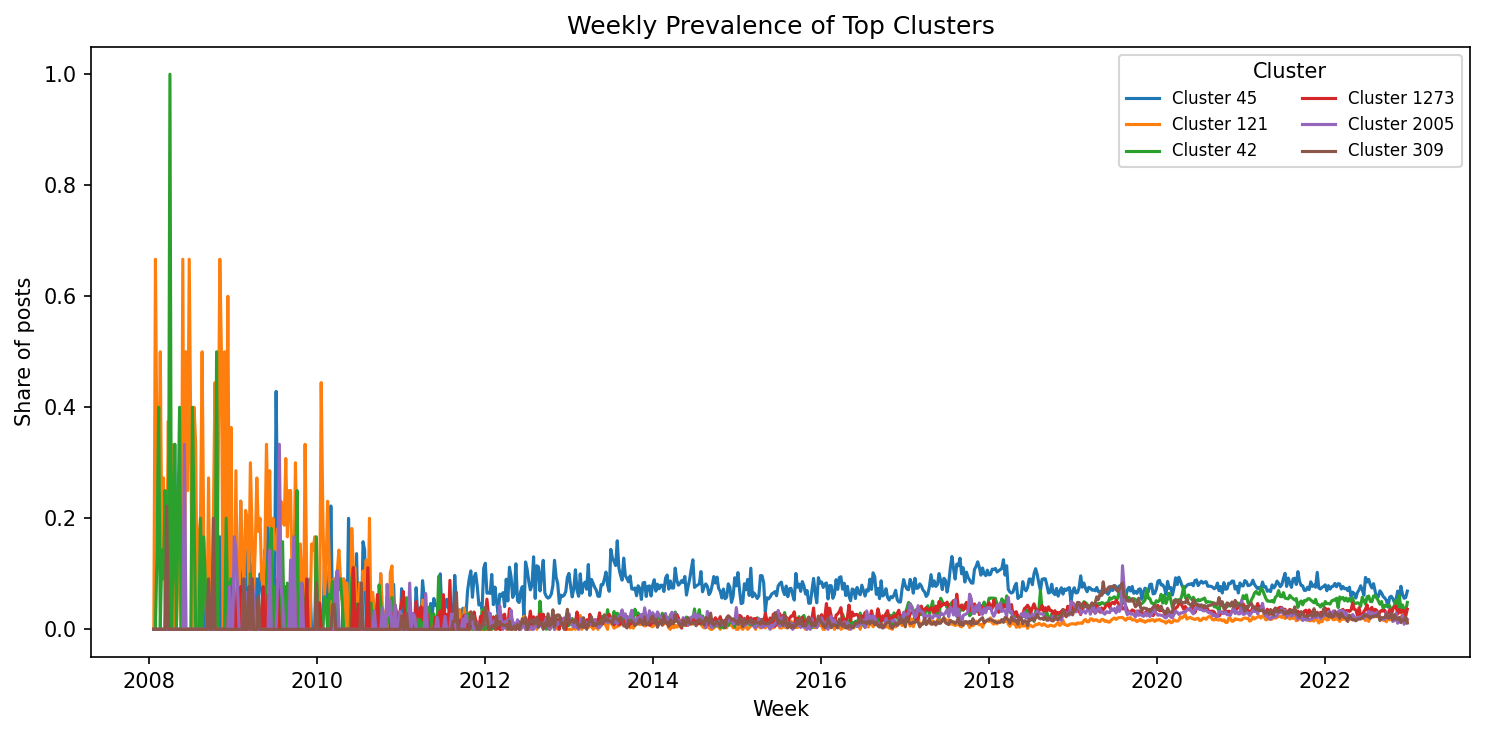

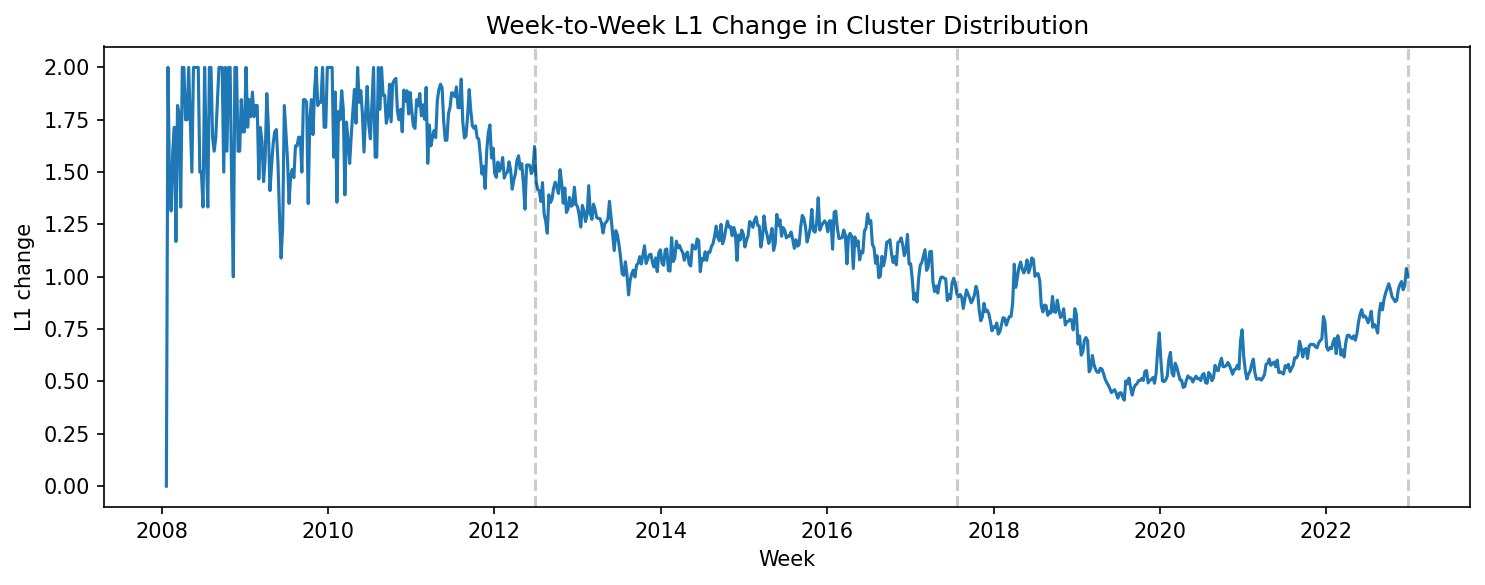

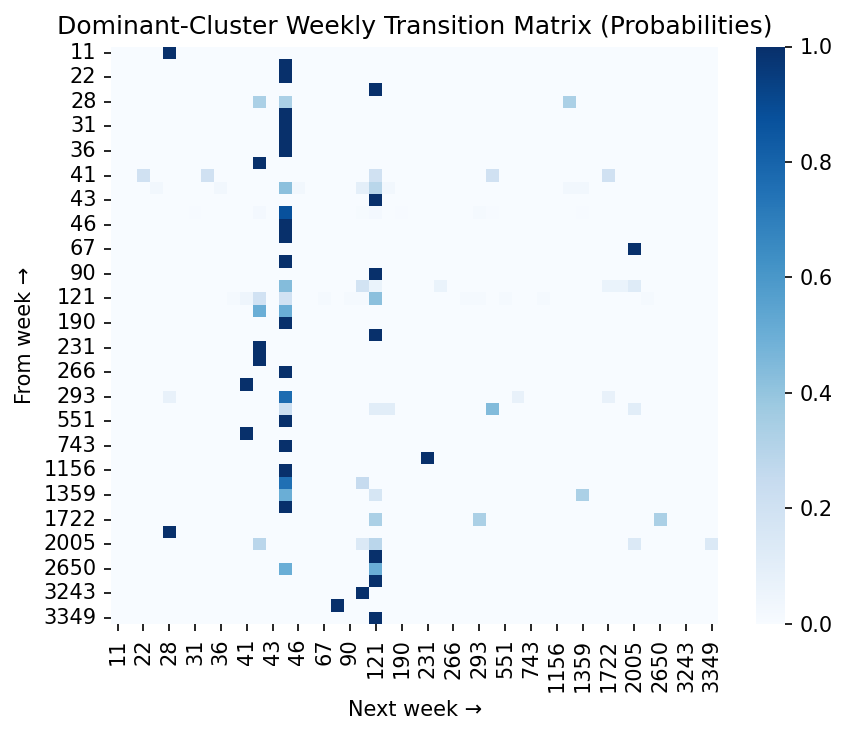

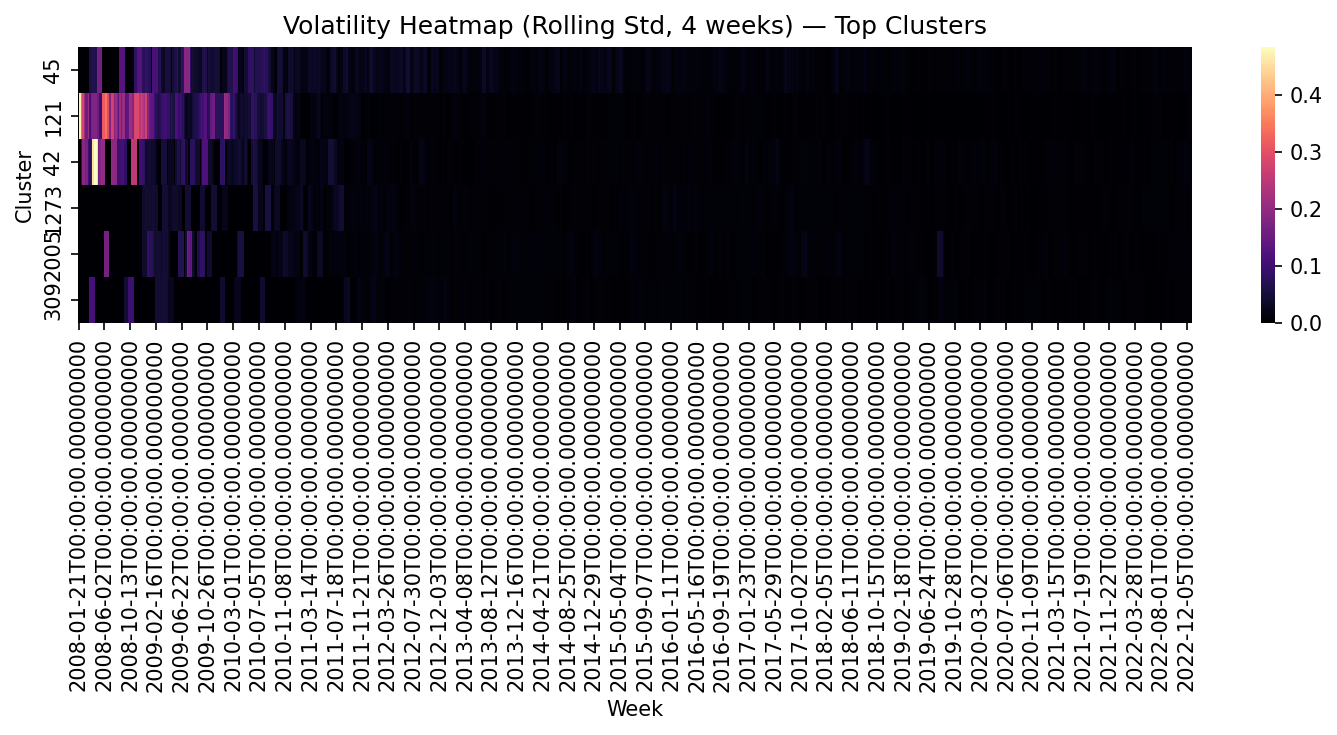

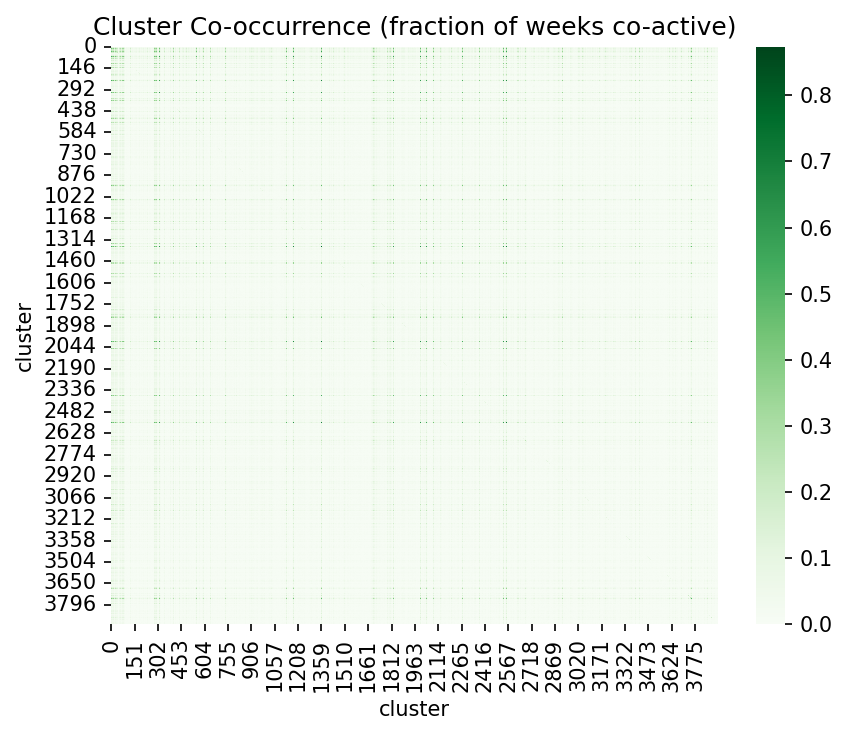

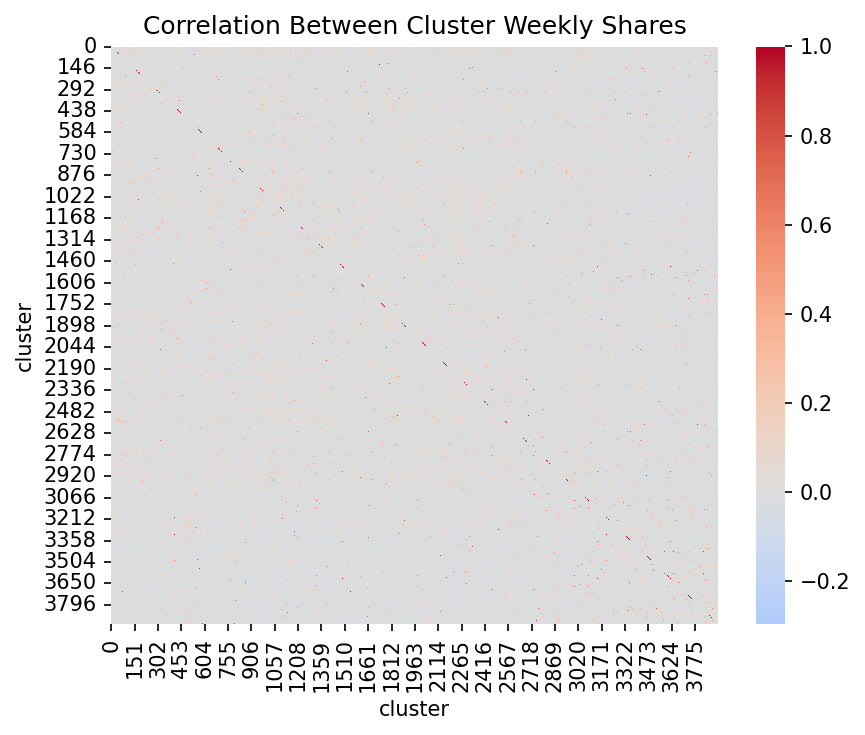

In [ ]:
# ==== Install (light) ====
!pip -q install ruptures

# ==== Imports ====
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 150

# --------------------------------------------------
# 1) Load weekly counts and compute weekly prevalence
# --------------------------------------------------
if os.path.exists("weekly_cluster_prevalence.csv"):
    pivot_share = pd.read_csv("weekly_cluster_prevalence.csv", parse_dates=['week'], index_col='week')
else:
    weekly = pd.read_csv("weekly_cluster_counts.csv")
    if not np.issubdtype(weekly['week'].dtype, np.datetime64):
        weekly['week'] = pd.to_datetime(weekly['week'], errors='coerce')

    weekly = weekly[weekly['cluster'] != -1].copy()
    weekly['total_week'] = weekly.groupby('week')['count'].transform('sum')
    weekly['share'] = weekly['count'] / weekly['total_week'].replace(0, np.nan)

    pivot_share = weekly.pivot_table(index='week', columns='cluster', values='share', aggfunc='sum').fillna(0.0)
    pivot_share.sort_index(inplace=True)
    pivot_share.to_csv("weekly_cluster_prevalence.csv")

# pick top K clusters by total prevalence mass across time
totals = pivot_share.sum(axis=0).sort_values(ascending=False)
topK = 6
top_clusters = totals.head(topK).index.tolist()

# Plot weekly prevalence (topK)
plt.figure(figsize=(10,5))
for c in top_clusters:
    plt.plot(pivot_share.index, pivot_share[c], label=f"Cluster {c}")
plt.legend(title="Cluster", ncol=2, fontsize=8)
plt.title("Weekly Prevalence of Top Clusters")
plt.xlabel("Week"); plt.ylabel("Share of posts")
plt.tight_layout(); plt.savefig("fig_weekly_prevalence_topK.png"); plt.show()

# --------------------------------------------------
# 2) Week-to-week L1 change + peaks + change-points
# --------------------------------------------------
delta_l1 = pivot_share.diff().abs().sum(axis=1).fillna(0.0)
delta_df = pd.DataFrame({"week": delta_l1.index, "l1_change": delta_l1.values})
delta_df.to_csv("weekly_l1_change.csv", index=False)

# peaks via z-score threshold
z = (delta_l1 - delta_l1.mean()) / (delta_l1.std(ddof=0) if delta_l1.std(ddof=0) > 0 else 1.0)
peaks = z[z > 2.0]
peaks_df = pd.DataFrame({"week": peaks.index, "zscore": peaks.values, "l1_change": delta_l1.loc[peaks.index].values})
peaks_df.to_csv("weekly_l1_change_peaks.csv", index=False)

# ruptures change-points on L1 series (simple PELT)
signal = delta_l1.values.reshape(-1, 1)
model = rpt.Pelt(model="l2").fit(signal)
penalty = np.percentile(delta_l1.values, 80) * 5 + 1e-6
bkpts = model.predict(pen=penalty)
cp_weeks = [pivot_share.index[i-1] for i in bkpts if 0 < i <= len(pivot_share)]
pd.DataFrame({"change_point_week": cp_weeks}).to_csv("change_points_weeks.csv", index=False)

plt.figure(figsize=(10,4))
plt.plot(delta_l1.index, delta_l1.values, linewidth=1.5)
for w in cp_weeks:
    plt.axvline(w, color='k', linestyle='--', alpha=0.2)
plt.scatter(peaks.index, delta_l1.loc[peaks.index].values, s=18)
plt.title("Week-to-Week L1 Change in Cluster Distribution")
plt.xlabel("Week"); plt.ylabel("L1 change")
plt.tight_layout(); plt.savefig("fig_weekly_l1_change.png"); plt.show()

# --------------------------------------------------
# 3) Markov transition matrix over dominant weekly clusters
# --------------------------------------------------
dom = pivot_share.idxmax(axis=1).dropna()
weeks_sorted = dom.index.to_list()
transitions = [(int(dom.iloc[i]), int(dom.iloc[i+1])) for i in range(len(weeks_sorted)-1)]
trans_df = pd.DataFrame(transitions, columns=["from", "to"])
counts = trans_df.value_counts().rename("n").reset_index()

states = sorted(set(counts['from']).union(set(counts['to'])))
T = pd.DataFrame(0.0, index=states, columns=states)
for _, row in counts.iterrows():
    T.loc[row['from'], row['to']] += row['n']
T_prob = T.div(T.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
T_prob.to_csv("dominant_transition_matrix.csv")

plt.figure(figsize=(6,5))
sns.heatmap(T_prob, annot=False, cmap="Blues")
plt.title("Dominant-Cluster Weekly Transition Matrix (Probabilities)")
plt.xlabel("Next week →"); plt.ylabel("From week →")
plt.tight_layout(); plt.savefig("fig_transition_matrix.png"); plt.show()

pd.DataFrame({"week": dom.index, "dominant_cluster": dom.values}).to_csv("dominant_cluster_by_week.csv", index=False)

# --------------------------------------------------
# 4) Volatility tracking (rolling std of weekly share per cluster)
# --------------------------------------------------
# 4-week rolling window; adjust if your weeks are sparse
vol_rolling = pivot_share.rolling(window=4, min_periods=2).std().fillna(0.0)
vol_rolling.to_csv("weekly_volatility_rolling4w.csv")

# Plot heatmap for top clusters
plt.figure(figsize=(10,5))
sns.heatmap(vol_rolling[top_clusters].T, cmap="magma", cbar=True)
plt.title("Volatility Heatmap (Rolling Std, 4 weeks) — Top Clusters")
plt.xlabel("Week"); plt.ylabel("Cluster")
plt.tight_layout(); plt.savefig("fig_volatility_heatmap_topK.png"); plt.show()

# --------------------------------------------------
# 5) Co-occurrence & correlation between clusters
# --------------------------------------------------
# Co-occurrence: weeks where both clusters have non-zero share
present = (pivot_share > 0).astype(int)
co_occ = present.T @ present  # counts of weeks co-active
co_occ.to_csv("cluster_cooccurrence_weeks.csv")

plt.figure(figsize=(6,5))
sns.heatmap(co_occ / max(1, len(pivot_share)), cmap="Greens")
plt.title("Cluster Co-occurrence (fraction of weeks co-active)")
plt.tight_layout(); plt.savefig("fig_cooccurrence_heatmap.png"); plt.show()

# Correlation across weekly shares
corr = pivot_share.corr().fillna(0.0)
corr.to_csv("cluster_share_correlation.csv")

plt.figure(figsize=(6,5))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Between Cluster Weekly Shares")
plt.tight_layout(); plt.savefig("fig_correlation_heatmap.png"); plt.show()

# --------------------------------------------------
# 6) Clustering quality (Silhouette & DBI) on UMAP-reduced space, excl. noise
# --------------------------------------------------
try:
    X = np.load("sbert_umap_embeddings.npy")
    labels = np.load("cluster_labels.npy")
    mask = labels != -1
    if mask.sum() > 10 and len(np.unique(labels[mask])) > 1:
        sil = silhouette_score(X[mask], labels[mask])
        dbi = davies_bouldin_score(X[mask], labels[mask])
        print(f"Silhouette (excl. noise): {sil:.4f}")
        print(f"Davies–Bouldin (excl. noise): {dbi:.4f}")
        with open("clustering_quality.txt", "w") as f:
            f.write(f"Silhouette (excl. noise): {sil:.6f}\nDavies–Bouldin (excl. noise): {dbi:.6f}\n")
    else:
        print("Not enough non-noise points/clusters for quality metrics.")
except Exception as e:
    print("Quality evaluation skipped:", e)

# --------------------------------------------------
# 7) TF-IDF cluster labeling (keywords per cluster)
# --------------------------------------------------
# Needs dataset_with_clusters.csv with a text column.
df = pd.read_csv("dataset_with_clusters.csv")

# Build a 'text' column if not present
if 'text' not in df.columns:
    title = df['title'].fillna('') if 'title' in df.columns else ''
    body  = df['body'].fillna('')  if 'body'  in df.columns else ''
    df['text'] = (title + ' ' + body).astype(str)

# Exclude noise
df_nn = df[df['cluster'] != -1].copy()
df_nn['text'] = df_nn['text'].astype(str)

# Global sample to fit vectorizer (keeps memory modest)
GLOBAL_MAX = min(200_000, len(df_nn))
global_sample = df_nn.sample(GLOBAL_MAX, random_state=42) if len(df_nn) > GLOBAL_MAX else df_nn

# Vectorizer: 1–3 grams, English stopwords
vec = TfidfVectorizer(stop_words='english', ngram_range=(1,3), max_features=50_000, min_df=5)
X_global = vec.fit_transform(global_sample['text'].values)
terms = np.array(vec.get_feature_names_out())

# For each cluster: transform (no refit), compute mean TF-IDF, take top-k terms
rows = []
TOPK = 15
MAX_PER_CLUSTER = 10_000  # cap for transform
for c, csize in df_nn['cluster'].value_counts().sort_index().items():
    sub = df_nn[df_nn['cluster'] == c]
    if len(sub) == 0:
        continue
    if len(sub) > MAX_PER_CLUSTER:
        sub = sub.sample(MAX_PER_CLUSTER, random_state=42)
    Xc = vec.transform(sub['text'].values)
    mean_scores = np.asarray(Xc.mean(axis=0)).ravel()
    top_idx = mean_scores.argsort()[::-1][:TOPK]
    top_terms = terms[top_idx].tolist()
    rows.append({"cluster": int(c), "n_posts": int(csize), "keywords": ", ".join(top_terms)})

kw_df = pd.DataFrame(rows).sort_values("n_posts", ascending=False)
kw_df.to_csv("cluster_keywords.csv", index=False)

# Also print a quick look for top clusters
print("\nTop cluster keywords:")
print(kw_df.head(10).to_string(index=False))
